# Classificação de Endometriose em Imagens de Laparoscopia

**Projeto de Deep Learning — Python · TensorFlow · ResNet50V2 · Transfer Learning · Google Colab (GPU T4)**

| Componente | Descrição |
|---|---|
| Dataset | 1.022 imagens reais — 2 classes: *endometriosis* e *no_endometriosis* |
| Arquitetura | ResNet50V2 pré-treinada no ImageNet (Transfer Learning) |
| Estratégia | Treino em 2 fases: cabeçalho → fine-tuning das últimas 30 camadas |
| Ambiente | Google Colab com GPU NVIDIA T4 |

## Bloco 1 — Configuração do Ambiente e Carregamento do Dataset

Neste bloco preparamos todo o ambiente necessário para o projeto.
Importamos as bibliotecas de deep learning (TensorFlow), visualização (Matplotlib, Seaborn)
e métricas clínicas (Scikit-learn). Em seguida, montamos o Google Drive, extraímos
o dataset compactado e confirmamos que a GPU está disponível para acelerar o treino.

In [10]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tensorflow.keras import layers, callbacks
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
import zipfile
from google.colab import drive

drive.mount('/content/drive')
DATASET_PATH = '/content/drive/MyDrive/dataset/dataset_final.zip'  # ajuste o caminho

IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
DIRETORIO_BASE = '/content/dataset_final'

with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
    zip_ref.extractall(DIRETORIO_BASE)

DIRETORIO_BASE = '/content/dataset_final/dataset_final'

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Bloco 2 — Divisão do Dataset em Treino, Validação e Teste

Dividimos as 1.022 imagens em três conjuntos independentes:

| Conjunto | Proporção | Qtd. aprox. | Função |
|---|---|---|---|
| Treino | 70% | ~716 imagens | O modelo aprende com estas |
| Validação | 15% | ~153 imagens | Monitoramos o progresso durante o treino |
| Teste | 15% | ~153 imagens | Avaliação final imparcial — nunca vistas antes |

A separação garante que os resultados finais reflitam o desempenho real do modelo
em imagens completamente desconhecidas — assim como seria em um ambiente clínico real.
O pipeline é otimizado com `cache().shuffle().prefetch()` para carregar os dados
em paralelo ao processamento, reduzindo o tempo de espera entre épocas.

In [12]:
# Carrega 70% para treino
dataset_treino = tf.keras.utils.image_dataset_from_directory(
    DIRETORIO_BASE,
    validation_split=0.30,   # reserva 30% para val+teste
    subset='training',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Carrega os 30% restantes
dataset_resto = tf.keras.utils.image_dataset_from_directory(
    DIRETORIO_BASE,
    validation_split=0.30,
    subset='validation',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Divide os 30% ao meio: 15% validação + 15% teste
n_batches_val  = len(dataset_resto) // 2
dataset_val    = dataset_resto.take(n_batches_val)
dataset_teste  = dataset_resto.skip(n_batches_val)

class_names = dataset_treino.class_names
print(f'Classes: {class_names}')

# Otimização de velocidade: carrega o próximo lote enquanto o atual é processado
AUTOTUNE       = tf.data.AUTOTUNE
dataset_treino = dataset_treino.cache().shuffle(1000).prefetch(AUTOTUNE)
dataset_val    = dataset_val.cache().prefetch(AUTOTUNE)
dataset_teste  = dataset_teste.cache().prefetch(AUTOTUNE)

print(f'Treino   : ~{len(dataset_treino) * BATCH_SIZE} imagens')
print(f'Validação: ~{len(dataset_val)    * BATCH_SIZE} imagens')
print(f'Teste    : ~{len(dataset_teste)  * BATCH_SIZE} imagens')

Found 1022 files belonging to 2 classes.
Using 716 files for training.
Found 1022 files belonging to 2 classes.
Using 306 files for validation.
Classes: ['endometriosis', 'no_endometriosis']
Treino   : ~736 imagens
Validação: ~160 imagens
Teste    : ~160 imagens


## Bloco 3 — Data Augmentation (Aumento de Dados)

Com apenas 1.022 imagens, o modelo correria o risco de **memorizar** os exemplos em vez de
**aprender padrões**. O Data Augmentation resolve isso gerando variações artificiais de cada
imagem durante o treino:

| Transformação | O que faz |
|---|---|
| RandomFlip | Espelha a imagem horizontalmente e verticalmente |
| RandomRotation | Rotaciona em até ±20° |
| RandomZoom | Aplica zoom de ±10% |
| RandomContrast | Varia o contraste em ±20% |
| RandomBrightness | Varia o brilho em ±15% |

As variações de contraste e brilho são especialmente importantes para imagens laparoscópicas,
onde a iluminação da câmera pode variar entre equipamentos e procedimentos.

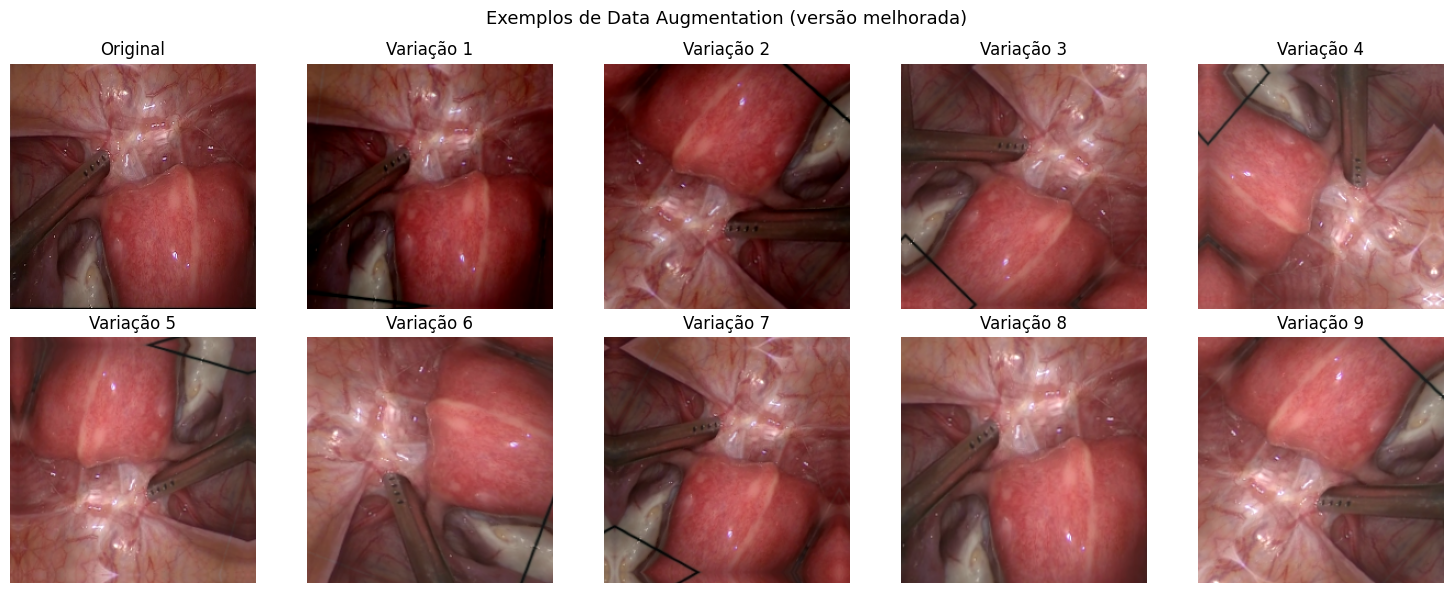

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.15),
], name='augmentation')

# Visualizar o efeito das novas transformações
for images, _ in dataset_treino.take(1):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes[0, 0].imshow(images[0].numpy().astype('uint8'))
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    for i, ax in enumerate(axes.flatten()[1:]):
        aug = data_augmentation(images[:1], training=True)
        ax.imshow(tf.clip_by_value(aug[0], 0, 255).numpy().astype('uint8'))
        ax.set_title(f'Variação {i+1}')
        ax.axis('off')
    plt.suptitle('Exemplos de Data Augmentation (versão melhorada)', fontsize=13)
    plt.tight_layout()
    plt.show()
    break

## Bloco 4 — Balanceamento das Classes (Pesos)

O dataset apresenta um leve desbalanceamento entre as classes.
Se o modelo treinar sem compensação, tende a privilegiar a classe majoritária.

Para corrigir isso, calculamos automaticamente um **peso proporcional** para cada classe.
Durante o treino, errar um exemplo da classe com maior peso gera uma penalidade
proporcionalmente maior — forçando o modelo a prestar igual atenção às duas classes.

| Classe | Peso calculado | Interpretação |
|---|---|---|
| endometriosis | 0.932 | Classe ligeiramente mais frequente no treino |
| no_endometriosis | 1.078 | Penalizada proporcionalmente mais para compensar |

In [14]:
labels_treino = np.concatenate([y.numpy() for _, y in dataset_treino]).astype(int)

# np.unique detecta as classes presentes automaticamente (evita erro se faltar alguma)
classes_unicas = np.unique(labels_treino)

pesos_array = compute_class_weight(
    class_weight='balanced',
    classes=classes_unicas,
    y=labels_treino
)
class_weights = {int(c): float(p) for c, p in zip(classes_unicas, pesos_array)}

print('Pesos calculados:')
for idx, nome in enumerate(class_names):
    print(f'  Classe "{nome}" (índice {idx}): peso = {pesos_array[idx]:.3f}')

print('\nInterpretação: um erro na classe com maior peso conta proporcionalmente mais no treino.')

Pesos calculados:
  Classe "endometriosis" (índice 0): peso = 0.932
  Classe "no_endometriosis" (índice 1): peso = 1.078

Interpretação: um erro na classe com maior peso conta proporcionalmente mais no treino.


## Bloco 5 — Construção do Modelo (Transfer Learning)

Utilizamos a **ResNet50V2** pré-treinada no ImageNet como base — uma rede com 50 camadas
que já "sabe" reconhecer bordas, texturas e formas a partir de milhões de imagens.
Aproveitamos esse conhecimento e adicionamos um cabeçalho customizado para a tarefa médica:

```
Input (224×224×3)
    ↓  Data Augmentation
    ↓  ResNet50V2 (congelada na Fase 1)
    ↓  GlobalAveragePooling2D  →  2.048 valores por imagem
    ↓  BatchNormalization
    ↓  Dense(256) → Dropout(0.4)
    ↓  Dense(128) → Dropout(0.3)
    ↓  Dense(1, sigmoid)  →  probabilidade de endometriose
```

Total: **24,1 milhões** de parâmetros. Na Fase 1, apenas **561.665** são treináveis (cabeçalho).

In [15]:
# Base pré-treinada (começa congelada)
base_model = tf.keras.applications.ResNet50V2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Cabeçalho melhorado
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

print('Parâmetros treináveis na Fase 1 (apenas o cabeçalho):')
print(f'  Total     : {model.count_params():,}')
treinaveis = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'  Treináveis: {treinaveis:,}  ← apenas o cabeçalho')

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parâmetros treináveis na Fase 1 (apenas o cabeçalho):
  Total     : 24,130,561
  Treináveis: 561,665  ← apenas o cabeçalho


## Bloco 6 — Fase 1: Treino do Cabeçalho

Na primeira fase, a ResNet permanece **congelada** — ela não atualiza seus pesos.
Treinamos apenas o cabeçalho, ensinando-o a combinar os padrões detectados pela ResNet
para identificar endometriose.

| Parâmetro | Valor | Motivo |
|---|---|---|
| Otimizador | Adam (lr=0.0001) | Taxa padrão para convergência estável |
| Loss | Binary Crossentropy | Classificação binária |
| EarlyStopping | patience=7, monitor=val_auc | Para quando AUC não melhora |
| ModelCheckpoint | monitor=val_auc | Salva automaticamente o melhor modelo |
| Class weights | Sim | Compensa o desbalanceamento |

O treino rodou as 20 épocas completas, atingindo **val_auc = 0.9285** na época 19.

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase1 = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max'
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6
    ),
    callbacks.ModelCheckpoint(
        '/content/melhor_fase1.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

print('=== FASE 1: Treinando o cabeçalho (ResNet congelada) ===')
history_fase1 = model.fit(
    dataset_treino,
    epochs=20,
    validation_data=dataset_val,  # CORRETO: valida no conjunto de validação (não no teste)
    callbacks=callbacks_fase1,
    class_weight=class_weights
)

=== FASE 1: Treinando o cabeçalho (ResNet congelada) ===
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 337ms/step - accuracy: 0.5642 - auc: 0.5928 - loss: 0.8001 - precision: 0.5370 - recall: 0.4367 - val_accuracy: 0.6250 - val_auc: 0.7592 - val_loss: 0.6439 - val_precision: 0.7917 - val_recall: 0.4318 - learning_rate: 1.0000e-04
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 0.6690 - auc: 0.7325 - loss: 0.6429 - precision: 0.6301 - recall: 0.6928 - val_accuracy: 0.7125 - val_auc: 0.8172 - val_loss: 0.5555 - val_precision: 0.8281 - val_recall: 0.6023 - learning_rate: 1.0000e-04
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.7193 - auc: 0.8026 - loss: 0.5503 - precision: 0.6785 - recall: 0.7500 - val_accuracy: 0.7188 - val_auc: 0.8508 - val_loss: 0.5226 - val_precision: 0.8413 - val_recall: 0.6023 - learning_rate: 1.0000e-04
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.7416 - auc: 0.8244 - loss: 0.5239 - precision: 0.7025 - recall: 0.

## Bloco 7 — Fase 2: Fine-Tuning

Na segunda fase, **descongelamos as últimas 30 camadas** da ResNet e retreinamos
com uma taxa de aprendizado 10× menor (1e-5). Isso permite que a rede ajuste
sutilmente seu "olhar" para reconhecer padrões específicos de imagens laparoscópicas,
sem esquecer o que aprendeu com o ImageNet.

| | Fase 1 | Fase 2 |
|---|---|---|
| Parâmetros treináveis | 561.665 | 15.005.185 |
| Learning rate | 1e-4 | 1e-5 (10× menor) |
| ResNet | Congelada | Últimas 30 camadas liberadas |

O EarlyStopping interrompeu na época 9 (sem melhoria após 8 épocas),
retornando automaticamente aos pesos do melhor modelo encontrado.

In [17]:
# Descongela apenas as últimas 30 camadas da ResNet
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

treinaveis_ft = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Parâmetros treináveis na Fase 2: {treinaveis_ft:,} (últimas 30 camadas da ResNet + cabeçalho)')

# Taxa de aprendizado MUITO menor para não destruir o que a ResNet já sabe
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 10x menor que a Fase 1
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase2 = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=8,
        restore_best_weights=True,
        mode='max'
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-8
    ),
    callbacks.ModelCheckpoint(
        '/content/melhor_modelo_final.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

print('=== FASE 2: Fine-tuning (últimas 30 camadas da ResNet) ===')
history_fase2 = model.fit(
    dataset_treino,
    epochs=20,
    validation_data=dataset_val,
    callbacks=callbacks_fase2,
    class_weight=class_weights
)

Parâmetros treináveis na Fase 2: 15,005,185 (últimas 30 camadas da ResNet + cabeçalho)
=== FASE 2: Fine-tuning (últimas 30 camadas da ResNet) ===
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 375ms/step - accuracy: 0.8366 - auc: 0.9219 - loss: 0.3583 - precision: 0.8152 - recall: 0.8373 - val_accuracy: 0.8125 - val_auc: 0.9281 - val_loss: 0.4217 - val_precision: 0.9143 - val_recall: 0.7273 - learning_rate: 1.0000e-05
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - accuracy: 0.8422 - auc: 0.9233 - loss: 0.3523 - precision: 0.8192 - recall: 0.8464 - val_accuracy: 0.8125 - val_auc: 0.9258 - val_loss: 0.4427 - val_precision: 0.9143 - val_recall: 0.7273 - learning_rate: 1.0000e-05
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.8506 - auc: 0.9398 - loss: 0.3136 - precision: 0.8399 - recall: 0.8373 - val_accuracy: 0.8000 - val_auc: 0.9262 - val_loss: 0.4413 - val_precision: 0.9118 - val_recall: 0.7045 - learning_rate: 1.0000e-05
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 21

## Bloco 8 — Curvas de Aprendizado

Visualizamos a evolução de 4 métricas ao longo das épocas das duas fases.
A linha pontilhada cinza indica onde a Fase 2 (fine-tuning) começou.

| Gráfico | O que indica |
|---|---|
| Loss | Quanto o modelo erra — deve diminuir |
| Acurácia | Percentual de acertos gerais |
| AUC-ROC | Capacidade de discriminar as classes — mais robusto que acurácia |
| Recall | Percentual de casos de endometriose detectados corretamente |

Linhas de treino e validação próximas indicam um modelo que **generaliza bem**
— ele aprendeu padrões reais, não decorou as imagens de treino.

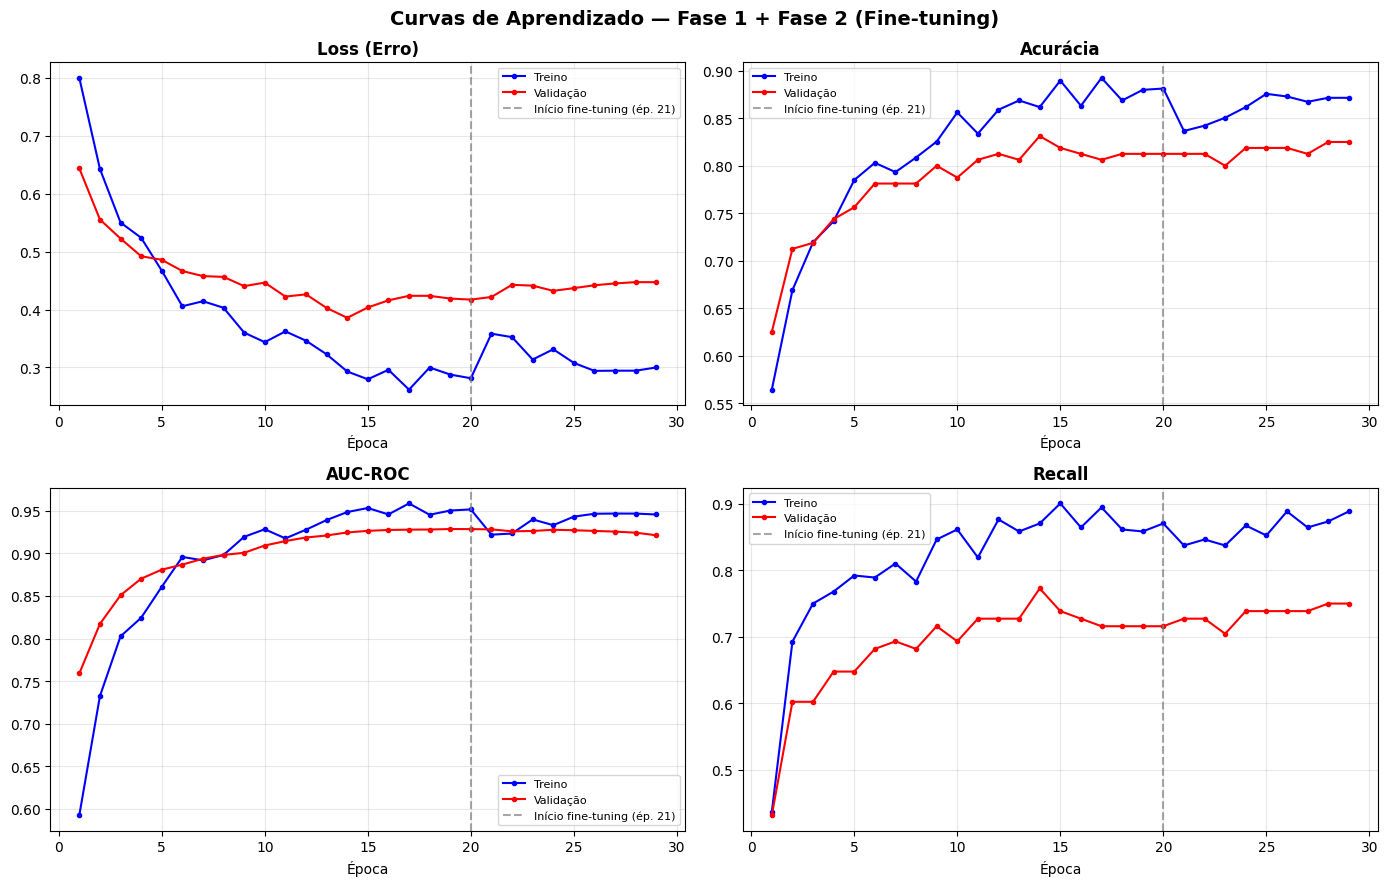

In [18]:
def plot_curvas(hist1, hist2, metrica, titulo, ax):
    v_treino = hist1.history[metrica] + hist2.history[metrica]
    v_val    = hist1.history[f'val_{metrica}'] + hist2.history[f'val_{metrica}']
    ep_fase1 = len(hist1.history[metrica])
    epocas   = range(1, len(v_treino) + 1)

    ax.plot(epocas, v_treino, 'b-o', markersize=3, label='Treino')
    ax.plot(epocas, v_val,    'r-o', markersize=3, label='Validação')
    ax.axvline(ep_fase1, color='gray', linestyle='--', alpha=0.7,
               label=f'Início fine-tuning (ép. {ep_fase1+1})')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Época')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_curvas(history_fase1, history_fase2, 'loss',      'Loss (Erro)',  axes[0,0])
plot_curvas(history_fase1, history_fase2, 'accuracy',  'Acurácia',    axes[0,1])
plot_curvas(history_fase1, history_fase2, 'auc',       'AUC-ROC',     axes[1,0])
plot_curvas(history_fase1, history_fase2, 'recall',    'Recall',      axes[1,1])

plt.suptitle('Curvas de Aprendizado — Fase 1 + Fase 2 (Fine-tuning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Bloco 9 — Threshold Otimizado pela Curva ROC

Todo classificador precisa de um ponto de corte: acima de qual probabilidade
o modelo deve emitir um diagnóstico positivo?

O valor padrão de **0.5** raramente é o ideal. Usamos o **Índice de Youden**
para encontrar automaticamente o threshold que maximiza simultaneamente:
- **Sensibilidade**: detectar quem realmente tem a doença
- **Especificidade**: não alarmar quem não tem

| Threshold | Tipo |
|---|---|
| 0.500 | Padrão (arbitrário) |
| **0.284** | **Otimizado pelo Índice de Youden** |

O threshold menor (0.284) indica que o modelo é mais cauteloso —
prefere suspeitar e investigar do que deixar passar um caso de endometriose.

In [19]:
# Carrega o melhor modelo salvo durante o treino
model = tf.keras.models.load_model('/content/melhor_modelo_final.keras')

# Coleta predições no conjunto de TESTE (nunca visto antes)
y_true       = []
y_pred_probs = []

for images, labels in dataset_teste:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Calcula a curva ROC completa
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# Índice de Youden: encontra o threshold que maximiza (sensibilidade + especificidade)
youden_idx      = np.argmax(tpr - fpr)
threshold_otimo = thresholds[youden_idx]

print(f'Threshold fixo anterior  : 0.500')
print(f'Threshold otimizado (novo): {threshold_otimo:.3f}')

# Aplica o threshold otimizado
y_pred_050 = (y_pred_probs >= 0.500).astype(int)
y_pred_opt = (y_pred_probs >= threshold_otimo).astype(int)

Threshold fixo anterior  : 0.500
Threshold otimizado (novo): 0.284


## Bloco 10 — Avaliação Completa no Conjunto de Teste

Avaliamos o modelo no conjunto de **teste** — imagens separadas desde o início
e nunca utilizadas durante o treino ou ajuste de parâmetros.

| Gráfico | O que mostra |
|---|---|
| Matriz de Confusão | Acertos e erros por classe (VP, FP, FN, VN) |
| Curva ROC | Desempenho em todos os thresholds — ponto vermelho = threshold ótimo |
| Distribuição de Probabilidades | Como o modelo separa as duas classes |

Quanto mais afastadas as distribuições das duas classes, mais confiante
e preciso é o modelo em sua separação.


===== COMPARAÇÃO: threshold 0.5 vs threshold otimizado =====

--- Threshold fixo = 0.50 ---
                  precision    recall  f1-score   support

   endometriosis       0.78      0.91      0.84        69
no_endometriosis       0.91      0.77      0.83        77

        accuracy                           0.84       146
       macro avg       0.84      0.84      0.84       146
    weighted avg       0.85      0.84      0.84       146

--- Threshold otimizado = 0.284 ---
                  precision    recall  f1-score   support

   endometriosis       0.91      0.90      0.91        69
no_endometriosis       0.91      0.92      0.92        77

        accuracy                           0.91       146
       macro avg       0.91      0.91      0.91       146
    weighted avg       0.91      0.91      0.91       146

AUC-ROC: 0.9612

Sensibilidade (recall): 0.922
Especificidade        : 0.899


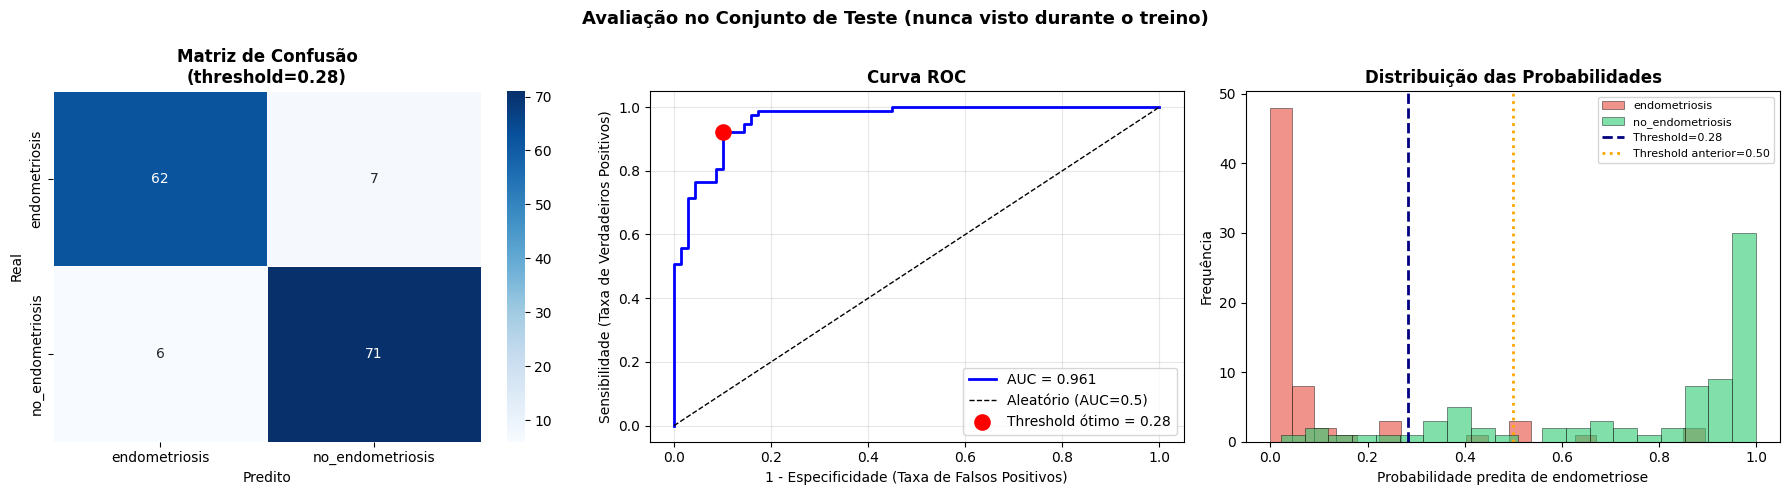

In [22]:
auc_score = roc_auc_score(y_true, y_pred_probs)

print('\n===== COMPARAÇÃO: threshold 0.5 vs threshold otimizado =====')
print(f'\n--- Threshold fixo = 0.50 ---')
print(classification_report(y_true, y_pred_050, target_names=class_names))
print(f'--- Threshold otimizado = {threshold_otimo:.3f} ---')
print(classification_report(y_true, y_pred_opt, target_names=class_names))
print(f'AUC-ROC: {auc_score:.4f}')

# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Matriz de Confusão ---
cm = confusion_matrix(y_true, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
axes[0].set_title(f'Matriz de Confusão\n(threshold={threshold_otimo:.2f})', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

tn, fp, fn, tp = cm.ravel()
sensibilidade  = tp / (tp + fn)
especificidade = tn / (tn + fp)
print(f'\nSensibilidade (recall): {sensibilidade:.3f}')
print(f'Especificidade        : {especificidade:.3f}')

# --- Curva ROC ---
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC=0.5)')
axes[1].scatter(fpr[youden_idx], tpr[youden_idx], c='red', s=120, zorder=5,
                label=f'Threshold ótimo = {threshold_otimo:.2f}')
axes[1].set_xlabel('1 - Especificidade (Taxa de Falsos Positivos)')
axes[1].set_ylabel('Sensibilidade (Taxa de Verdadeiros Positivos)')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Distribuição das probabilidades ---
for cls_idx, (nome, cor) in enumerate(zip(class_names, ['#e74c3c', '#2ecc71'])):
    mask = y_true == cls_idx
    axes[2].hist(y_pred_probs[mask], bins=20, alpha=0.6, color=cor,
                 label=nome, edgecolor='black', linewidth=0.5)
axes[2].axvline(threshold_otimo, color='navy', linestyle='--', lw=2,
                label=f'Threshold={threshold_otimo:.2f}')
axes[2].axvline(0.5, color='orange', linestyle=':', lw=2, label='Threshold anterior=0.50')
axes[2].set_xlabel('Probabilidade predita de endometriose')
axes[2].set_ylabel('Frequência')
axes[2].set_title('Distribuição das Probabilidades', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Avaliação no Conjunto de Teste (nunca visto durante o treino)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Bloco 11 — Grad-CAM: Explicabilidade Visual

O Grad-CAM (**Gradient-weighted Class Activation Mapping**) é uma técnica
que responde à pergunta: **"em que região da imagem o modelo está baseando sua decisão?"**

Para cada imagem exibimos três versões:
- **Original**: a imagem como o modelo recebeu
- **Mapa de calor**: regiões mais relevantes para a decisão (vermelho = maior ativação)
- **Sobreposição**: combinação das duas para facilitar a interpretação clínica

O título de cada linha indica se a predição foi **correta (verde)** ou **incorreta (vermelho)**,
junto com a probabilidade atribuída pelo modelo.
Isso permite avaliar se o modelo está "olhando" para as estruturas corretas da imagem.

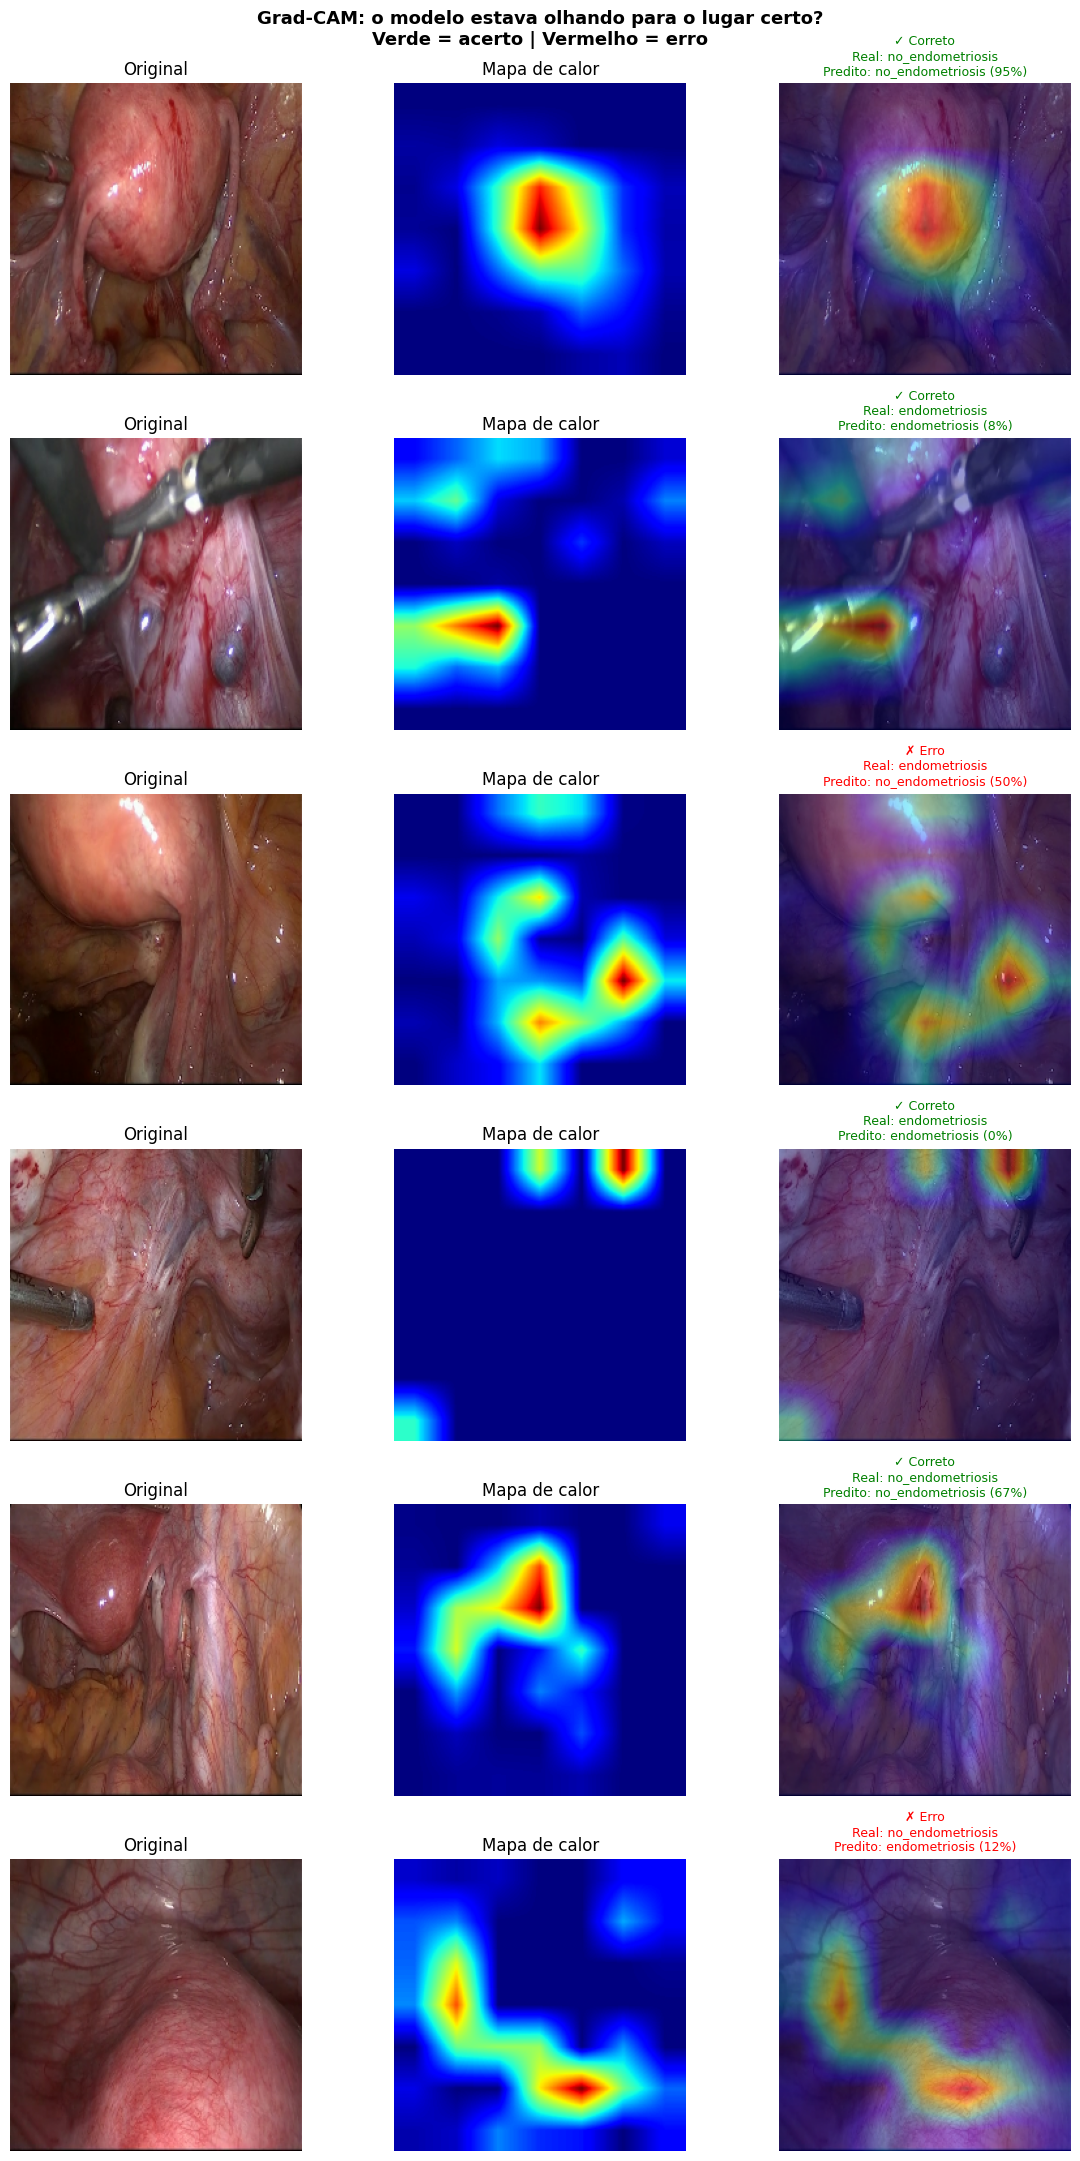

In [29]:
def gerar_gradcam(model, base_model, img_tensor):
    x_proc = tf.keras.applications.resnet_v2.preprocess_input(
        tf.cast(img_tensor, tf.float32)
    )

    prob = float(model(img_tensor, training=False).numpy().flatten()[0])

    head_start = next(
        i for i, l in enumerate(model.layers)
        if isinstance(l, tf.keras.layers.GlobalAveragePooling2D)
    )

    with tf.GradientTape() as tape:
        feature_maps = base_model(x_proc, training=False)
        tape.watch(feature_maps)

        out = feature_maps
        for layer in model.layers[head_start:]:
            if isinstance(layer, tf.keras.layers.Dropout):
                out = layer(out, training=False)
            else:
                out = layer(out)

        score = out[:, 0]

    grads        = tape.gradient(score, feature_maps)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = feature_maps[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), prob


# Coleta imagens de teste para visualizar
amostras, rotulos = [], []
for imgs, lbls in dataset_teste:
    for img, lbl in zip(imgs, lbls):
        if len(amostras) < 6:
            amostras.append(img)
            rotulos.append(int(lbl.numpy()))
    if len(amostras) >= 6:
        break

fig, axes = plt.subplots(6, 3, figsize=(12, 22))

for i, (img, rotulo_real) in enumerate(zip(amostras, rotulos)):
    img_tensor = tf.expand_dims(img, axis=0)
    heatmap, prob = gerar_gradcam(model, base_model, img_tensor)

    predito    = int(prob >= threshold_otimo)
    acertou    = predito == rotulo_real
    cor_titulo = 'green' if acertou else 'red'

    heatmap_resized = tf.squeeze(tf.image.resize(heatmap[..., tf.newaxis], (224, 224))).numpy()

    heatmap_color   = np.uint8(plt.cm.jet(heatmap_resized)[..., :3] * 255)
    img_uint8       = np.uint8(img.numpy())
    sobreposicao    = np.uint8(img_uint8 * 0.6 + heatmap_color * 0.4)

    axes[i, 0].imshow(img_uint8)
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap_resized, cmap='jet')
    axes[i, 1].set_title('Mapa de calor')
    axes[i, 1].axis('off')

    status = '✓ Correto' if acertou else '✗ Erro'
    axes[i, 2].imshow(sobreposicao)
    axes[i, 2].set_title(
        f'{status}\nReal: {class_names[rotulo_real]}\nPredito: {class_names[predito]} ({prob:.0%})',
        color=cor_titulo, fontsize=9
    )
    axes[i, 2].axis('off')

plt.suptitle('Grad-CAM: o modelo estava olhando para o lugar certo?\n'
             'Verde = acerto | Vermelho = erro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Bloco 12 — Dashboard de Métricas Clínicas

Reunimos todas as métricas relevantes em um único painel visual.
O código de cores indica o nível de desempenho:

| Cor | Faixa | Nível |
|---|---|---|
| Verde | ≥ 0.85 | Bom |
| Amarelo | 0.70 – 0.84 | Aceitável |
| Vermelho | < 0.70 | Atenção |

As métricas cobrem diferentes perspectivas clínicas:
- **Sensibilidade**: quantos casos de endometriose foram detectados
- **Especificidade**: quantos casos saudáveis foram corretamente identificados
- **VPP / VPN**: valor preditivo positivo e negativo
- **AUC-ROC**: desempenho geral independente do threshold

     RESULTADOS FINAIS — CONJUNTO DE TESTE
AUC-ROC             : 0.961  ███████████████████
Acurácia            : 0.911  ██████████████████
Sensibilidade       : 0.922  ██████████████████
Especificidade      : 0.899  █████████████████
Precisão (VPP)      : 0.910  ██████████████████
VPN                 : 0.912  ██████████████████
F1-Score            : 0.916  ██████████████████


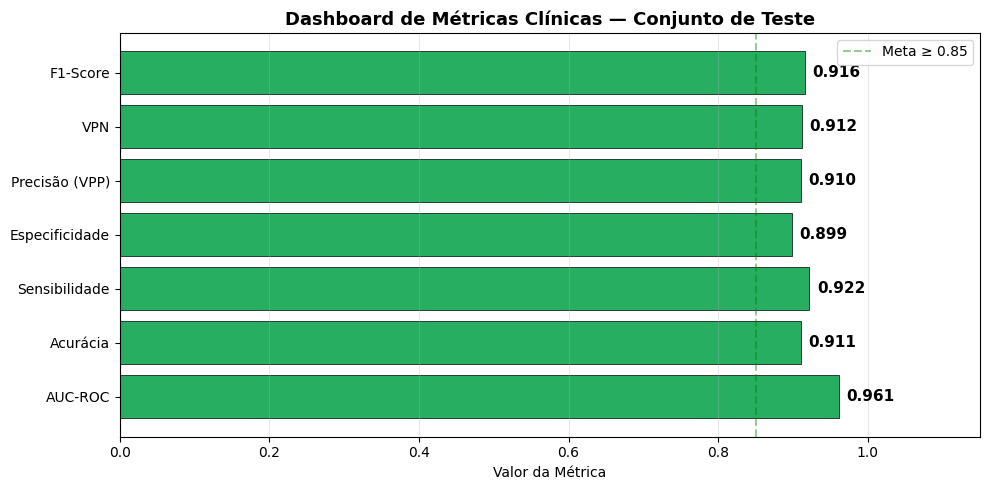

In [30]:
from sklearn.metrics import f1_score, accuracy_score, precision_score

tn, fp, fn, tp = confusion_matrix(y_true, y_pred_opt).ravel()

metricas = {
    'AUC-ROC'        : auc_score,
    'Acurácia'       : accuracy_score(y_true, y_pred_opt),
    'Sensibilidade'  : tp / (tp + fn),
    'Especificidade' : tn / (tn + fp),
    'Precisão (VPP)' : precision_score(y_true, y_pred_opt),
    'VPN'            : tn / (tn + fn) if (tn + fn) > 0 else 0,
    'F1-Score'       : f1_score(y_true, y_pred_opt)
}

print('=' * 45)
print('     RESULTADOS FINAIS — CONJUNTO DE TESTE')
print('=' * 45)
for nome, val in metricas.items():
    barra = '█' * int(val * 20)
    print(f'{nome:20s}: {val:.3f}  {barra}')
print('=' * 45)

fig, ax = plt.subplots(figsize=(10, 5))
nomes = list(metricas.keys())
vals  = list(metricas.values())
cores = ['#27ae60' if v >= 0.85 else '#f39c12' if v >= 0.70 else '#e74c3c' for v in vals]
bars  = ax.barh(nomes, vals, color=cores, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
ax.axvline(0.85, color='green', linestyle='--', alpha=0.4, label='Meta ≥ 0.85')
ax.set_xlim(0, 1.15)
ax.set_xlabel('Valor da Métrica')
ax.set_title('Dashboard de Métricas Clínicas — Conjunto de Teste', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Bloco 13 — Exportação do Modelo

Ao final do treino, exportamos o modelo em dois formatos:

| Formato | Uso | Descrição |
|---|---|---|
| `.keras` | Ambiente Python | Modelo completo para pesquisa e re-treino |
| `.tflite` | Dispositivos móveis | Versão comprimida para uso em campo |

Também salvamos um arquivo `modelo_metadata.json` com as configurações completas:
classes, threshold otimizado, tamanho de entrada e métricas finais.
Isso permite que qualquer pessoa reproduza ou utilize o modelo sem precisar
executar o treino novamente.

In [31]:
import json

# Salva modelo completo
model.save('/content/endometriose_modelo_final.keras')
print('Modelo .keras salvo.')

# Converte para TensorFlow Lite (uso em celular/tablet)
converter    = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('/content/endometriose_modelo.tflite', 'wb') as f:
    f.write(tflite_model)
print(f'Modelo TFLite salvo ({len(tflite_model)/1e6:.1f} MB).')

# Salva metadados com as configurações e resultados
metadata = {
    'classes'         : class_names,
    'threshold'       : float(threshold_otimo),
    'img_size'        : list(IMG_SIZE),
    'arquitetura'     : 'ResNet50V2 + cabeçalho melhorado + fine-tuning',
    'metricas_teste'  : {k: round(float(v), 4) for k, v in metricas.items()}
}
with open('/content/modelo_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print('\nMetadados do modelo:')
print(json.dumps(metadata, indent=2, ensure_ascii=False))

# Download automático dos arquivos
from google.colab import files
for arq in ['/content/endometriose_modelo_final.keras',
            '/content/endometriose_modelo.tflite',
            '/content/modelo_metadata.json']:
    files.download(arq)
print('\nDownload iniciado!')

Modelo .keras salvo.
Saved artifact at '/tmp/tmptg_2s07s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139017693067984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139017693068944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139017693067792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139017693069136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139017693067216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139017693068752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139017693067024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139017693067600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139017693068176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139017693068560: TensorSpec(shape=(), dtype=tf.resource, name=

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download iniciado!
